# AQSM Carrier Quality Testbench

Runs carrier-image quality checks for `r = 1`, `r = 2`, and `r = 3`, then compares each original carrier with its watermarked carrier using `PSNR` and `SSIM`.

References used inside this repo: `paper_analysis/paper_analysis.md`, `paper_analysis/aqsm_2x2_step_by_step.md`, and `paper_analysis/adaptive quantum scaling model.pdf`. Metric naming follows the scikit-image metrics API: https://scikit-image.org/docs/stable/api/skimage.metrics.html.

Note: the package implementation remains extraction-complete only for the paper's fully specified `r = 1` path. This notebook uses the paper's generic AQSM block-set counts for `r = 2` and `r = 3` carrier-quality embedding only; it does not claim `r > 1` extraction support.


In [1]:
from collections import defaultdict
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

from aqsm_embedding import (
    AQSMBuildResult,
    AQSMWatermarkBuilder,
    BitPlaneDecomposer,
    HDWMEmbedder,
    HistogramAnalyzer,
    ImageFileLoader,
    QuantumBlockAggregator,
    ScaleParameterCalculator,
    USCSIPISampleDataset,
)

R_VALUES = (1, 2, 3)
CARRIER_SIDE = 512
BRANCH_ORDER = ("tau1=0", "tau1=1,tau2=1", "tau1=1,tau2=0")
HISTOGRAM_DENOMINATOR_MODE = "natural"
USE_DERIVED_DARK_BRANCH_VARIANTS = True
CACHE_DIR = Path("example_outputs") / "usc_sipi_samples"

plt.rcParams["figure.dpi"] = 120


In [2]:
def branch_label(parameters):
    if parameters.tau1 == 0:
        return "tau1=0"
    return f"tau1=1,tau2={parameters.tau2}"


def invert_image(image):
    return [[255 - value for value in row] for row in image]


def print_options(title, options):
    print(title)
    for index, (key, spec) in enumerate(options.items(), start=1):
        print(f"  {index:02d}. {key:<34} {spec.image_id:<10} {spec.description}")


def to_array(image):
    return np.asarray(image, dtype=np.float64)


def psnr(reference, test, data_range=255.0):
    reference_array = to_array(reference)
    test_array = to_array(test)
    mse = np.mean((reference_array - test_array) ** 2)
    if mse == 0:
        return math.inf
    return 10 * math.log10((data_range ** 2) / mse)


def gaussian_kernel(size=11, sigma=1.5):
    offsets = np.arange(size, dtype=np.float64) - (size // 2)
    kernel = np.exp(-(offsets ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def gaussian_filter(image, kernel):
    pad = len(kernel) // 2
    height, width = image.shape

    padded_x = np.pad(image, ((0, 0), (pad, pad)), mode="reflect")
    temp = np.zeros_like(image, dtype=np.float64)
    for offset, weight in enumerate(kernel):
        temp += weight * padded_x[:, offset : offset + width]

    padded_y = np.pad(temp, ((pad, pad), (0, 0)), mode="reflect")
    output = np.zeros_like(image, dtype=np.float64)
    for offset, weight in enumerate(kernel):
        output += weight * padded_y[offset : offset + height, :]
    return output


def ssim(reference, test, data_range=255.0):
    reference_array = to_array(reference)
    test_array = to_array(test)
    kernel = gaussian_kernel()

    mu_ref = gaussian_filter(reference_array, kernel)
    mu_test = gaussian_filter(test_array, kernel)

    mu_ref_sq = mu_ref * mu_ref
    mu_test_sq = mu_test * mu_test
    mu_ref_test = mu_ref * mu_test

    sigma_ref_sq = gaussian_filter(reference_array * reference_array, kernel) - mu_ref_sq
    sigma_test_sq = gaussian_filter(test_array * test_array, kernel) - mu_test_sq
    sigma_ref_test = gaussian_filter(reference_array * test_array, kernel) - mu_ref_test

    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    numerator = (2 * mu_ref_test + c1) * (2 * sigma_ref_test + c2)
    denominator = (mu_ref_sq + mu_test_sq + c1) * (sigma_ref_sq + sigma_test_sq + c2)
    return float(np.mean(numerator / denominator))


def aggregate_blocks(blocks, levels, aggregator):
    current_blocks = list(blocks)
    for _ in range(levels):
        if len(current_blocks) % 4:
            raise ValueError("QBA input block count must be divisible by 4.")
        current_blocks = [
            aggregator.aggregate_four(*current_blocks[index : index + 4])
            for index in range(0, len(current_blocks), 4)
        ]
    return current_blocks


def build_aqsm_for_carrier_quality(bit_planes, scale_parameters, r1_builder, aggregator):
    if scale_parameters.scale_factor == 1:
        return r1_builder.build(bit_planes, scale_parameters)

    low_half_set = [bit_planes[f"w{i}"] for i in range(1, 5)]
    high_half_set = [bit_planes[f"w{i}"] for i in range(5, 9)]
    block_sets = [low_half_set for _ in range(scale_parameters.alpha)]
    block_sets += [high_half_set for _ in range(scale_parameters.alpha + 2)]
    input_blocks = [block for block_set in block_sets for block in block_set]
    embedded_watermarks = aggregate_blocks(
        input_blocks,
        levels=scale_parameters.aggregation_level,
        aggregator=aggregator,
    )
    return AQSMBuildResult(
        embedded_watermarks=embedded_watermarks,
        declared_output_count=scale_parameters.q_outputs,
    )


def show_carrier_result(record):
    fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.8))
    images = (
        record["watermark_image"],
        record["carrier_image"],
        record["watermarked_carrier"],
    )
    titles = (
        f"Watermark\n{record['watermark_key']}",
        f"Original carrier\n{record['carrier_key']}",
        f"Watermarked carrier\nPSNR {record['psnr']:.3f} dB | SSIM {record['ssim']:.6f}",
    )
    for axis, image, title in zip(axes, images, titles):
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title, fontsize=8)
        axis.axis("off")
    fig.suptitle(f"r={record['r']} | {record['branch']}", fontsize=9)
    plt.tight_layout()
    plt.show()


In [3]:
dataset = USCSIPISampleDataset(CACHE_DIR)
watermark_options = dataset.watermark_options()
carrier_options = dataset.carrier_options()

print_options("Watermark source options:", watermark_options)
print()
print_options("Carrier options:", carrier_options)


Watermark source options:
  01. watermark_moon_256                 5.1.09     Moon surface, 256x256 grayscale
  02. watermark_aerial_256               5.1.10     Aerial, 256x256 grayscale
  03. watermark_airplane_256             5.1.11     Airplane, 256x256 grayscale
  04. watermark_clock_256                5.1.12     Clock, 256x256 grayscale
  05. watermark_resolution_chart_256     5.1.13     Resolution chart, 256x256 grayscale
  06. watermark_chemical_plant_256       5.1.14     Chemical plant, 256x256 grayscale

Carrier options:
  01. carrier_couple_512                 5.2.08     Couple, 512x512 grayscale
  02. carrier_aerial_512                 5.2.09     Aerial, 512x512 grayscale
  03. carrier_bridge_512                 5.2.10     Stream and bridge, 512x512 grayscale
  04. carrier_truck_512                  7.1.01     Truck, 512x512 grayscale
  05. carrier_airplane_512               7.1.02     Airplane, 512x512 grayscale
  06. carrier_tank_1_512                 7.1.03     Tank, 512

In [4]:
loader = ImageFileLoader()
watermark_paths = {key: dataset.download_sample(key) for key in watermark_options}
carrier_paths = {key: dataset.download_sample(key) for key in carrier_options}

carriers = {
    key: loader.load_grayscale(path, target_side=CARRIER_SIDE)
    for key, path in carrier_paths.items()
}

watermarks_by_r = {}
for r in R_VALUES:
    watermark_side = CARRIER_SIDE // (2 ** r)
    watermarks_by_r[r] = {
        key: loader.load_grayscale(path, target_side=watermark_side)
        for key, path in watermark_paths.items()
    }

print(f"Loaded {len(carriers)} carriers at {CARRIER_SIDE}x{CARRIER_SIDE}.")
for r in R_VALUES:
    print(f"Loaded {len(watermarks_by_r[r])} watermark sources at r={r}, side={CARRIER_SIDE // (2 ** r)}.")


Loaded 16 carriers at 512x512.
Loaded 6 watermark sources at r=1, side=256.
Loaded 6 watermark sources at r=2, side=128.
Loaded 6 watermark sources at r=3, side=64.


In [5]:
histogram_analyzer = HistogramAnalyzer()
scale_calculator = ScaleParameterCalculator()
reference_carrier = next(iter(carriers.values()))


def analyze_variant(r, key, source_key, description, image, variant_kind):
    scale_parameters = scale_calculator.compute(image, reference_carrier)
    histogram_parameters = histogram_analyzer.analyze(
        image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    return {
        "r": r,
        "key": key,
        "source_key": source_key,
        "description": description,
        "variant_kind": variant_kind,
        "image": image,
        "histogram_parameters": histogram_parameters,
        "branch": branch_label(histogram_parameters),
    }


selected_watermarks = {}
for r in R_VALUES:
    variants = []
    for key, image in watermarks_by_r[r].items():
        variants.append(
            analyze_variant(
                r=r,
                key=key,
                source_key=key,
                description=watermark_options[key].description,
                image=image,
                variant_kind="natural",
            )
        )

    if USE_DERIVED_DARK_BRANCH_VARIANTS:
        for variant in list(variants):
            variants.append(
                analyze_variant(
                    r=r,
                    key=f"inverted_{variant['source_key']}",
                    source_key=variant["source_key"],
                    description=f"Inverted {variant['description']}",
                    image=invert_image(variant["image"]),
                    variant_kind="derived_inverted",
                )
            )

    by_branch = defaultdict(list)
    for variant in variants:
        by_branch[variant["branch"]].append(variant)

    selected_watermarks[r] = {}
    print(f"r={r} branch coverage:")
    for branch in BRANCH_ORDER:
        available = by_branch.get(branch, [])
        if not available:
            print(f"  {branch:<13} none")
            continue
        selected = available[0]
        selected_watermarks[r][branch] = selected
        print(
            f"  {branch:<13} selected {selected['key']} "
            f"({selected['variant_kind']}, T_dark={selected['histogram_parameters'].t_dark:.4f}, "
            f"T_bright={selected['histogram_parameters'].t_bright:.4f})"
        )
    print()


r=1 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4448, T_bright=0.5552)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0366, T_bright=0.9634)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9634, T_bright=0.0366)



r=2 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4351, T_bright=0.5649)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0399, T_bright=0.9601)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9601, T_bright=0.0399)

r=3 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4331, T_bright=0.5669)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0410, T_bright=0.9590)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9590, T_bright=0.0410)



In [6]:
bit_plane_decomposer = BitPlaneDecomposer()
r1_aqsm_builder = AQSMWatermarkBuilder()
aggregator = QuantumBlockAggregator()
hdwm_embedder = HDWMEmbedder()


def embed_for_carrier_quality(watermark_image, carrier_image):
    scale_parameters = scale_calculator.compute(watermark_image, carrier_image)
    histogram_parameters = histogram_analyzer.analyze(
        watermark_image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    bit_planes = bit_plane_decomposer.decompose(watermark_image)
    aqsm_result = build_aqsm_for_carrier_quality(
        bit_planes,
        scale_parameters,
        r1_builder=r1_aqsm_builder,
        aggregator=aggregator,
    )
    embedding_result = hdwm_embedder.embed(
        carrier_image=carrier_image,
        aqsm_result=aqsm_result,
        histogram_parameters=histogram_parameters,
        scale_parameters=scale_parameters,
    )
    return scale_parameters, histogram_parameters, aqsm_result, embedding_result


records = []
for r in R_VALUES:
    for branch in BRANCH_ORDER:
        if branch not in selected_watermarks[r]:
            continue
        watermark = selected_watermarks[r][branch]
        for carrier_key, carrier_image in carriers.items():
            scale_parameters, histogram_parameters, aqsm_result, embedding_result = embed_for_carrier_quality(
                watermark["image"],
                carrier_image,
            )
            watermarked_carrier = embedding_result.final_image
            records.append({
                "r": r,
                "branch": branch,
                "watermark_key": watermark["key"],
                "watermark_image": watermark["image"],
                "watermark_variant_kind": watermark["variant_kind"],
                "carrier_key": carrier_key,
                "carrier_image": carrier_image,
                "watermarked_carrier": watermarked_carrier,
                "scale_parameters": scale_parameters,
                "histogram_parameters": histogram_parameters,
                "embedded_aqsm_images": len(aqsm_result.embedded_watermarks),
                "psnr": psnr(carrier_image, watermarked_carrier),
                "ssim": ssim(carrier_image, watermarked_carrier),
            })
        print(f"Completed r={r}, {branch}: {len(carriers)} carriers")

print(f"Total carrier-quality runs: {len(records)}")


Completed r=1, tau1=0: 16 carriers


Completed r=1, tau1=1,tau2=1: 16 carriers


Completed r=1, tau1=1,tau2=0: 16 carriers


Completed r=2, tau1=0: 16 carriers


Completed r=2, tau1=1,tau2=1: 16 carriers


Completed r=2, tau1=1,tau2=0: 16 carriers


Completed r=3, tau1=0: 16 carriers


Completed r=3, tau1=1,tau2=1: 16 carriers


Completed r=3, tau1=1,tau2=0: 16 carriers
Total carrier-quality runs: 144


In [7]:
def summarize(records_subset):
    psnr_values = [record["psnr"] for record in records_subset]
    ssim_values = [record["ssim"] for record in records_subset]
    return {
        "count": len(records_subset),
        "avg_psnr": sum(psnr_values) / len(psnr_values),
        "min_psnr": min(psnr_values),
        "max_psnr": max(psnr_values),
        "avg_ssim": sum(ssim_values) / len(ssim_values),
        "min_ssim": min(ssim_values),
        "max_ssim": max(ssim_values),
    }


print("Carrier quality summary:")
print("r branch         carriers aqsm_imgs avg_psnr min_psnr max_psnr avg_ssim  min_ssim  max_ssim")
for r in R_VALUES:
    for branch in BRANCH_ORDER:
        subset = [record for record in records if record["r"] == r and record["branch"] == branch]
        if not subset:
            continue
        summary = summarize(subset)
        aqsm_images = subset[0]["embedded_aqsm_images"]
        print(
            f"{r:<1} {branch:<13} {summary['count']:>8} {aqsm_images:>9} "
            f"{summary['avg_psnr']:>8.3f} {summary['min_psnr']:>8.3f} {summary['max_psnr']:>8.3f} "
            f"{summary['avg_ssim']:>8.6f} {summary['min_ssim']:>8.6f} {summary['max_ssim']:>8.6f}"
        )


Carrier quality summary:
r branch         carriers aqsm_imgs avg_psnr min_psnr max_psnr avg_ssim  min_ssim  max_ssim
1 tau1=0              16         3   39.045   36.442   39.657 0.967596 0.930796 0.995263
1 tau1=1,tau2=1       16         3   37.724   37.115   39.359 0.963096 0.936462 0.997471
1 tau1=1,tau2=0       16         3   37.724   37.115   39.359 0.963096 0.936462 0.997471
2 tau1=0              16         1   51.106   51.014   51.146 0.997881 0.995322 0.999459
2 tau1=1,tau2=1       16         1   51.214   50.562   51.992 0.997947 0.995890 0.999636
2 tau1=1,tau2=0       16         1   51.214   50.562   51.992 0.997947 0.995890 0.999636
3 tau1=0              16         1   51.136   51.054   51.259 0.997714 0.994986 0.999342
3 tau1=1,tau2=1       16         1   51.187   50.737   51.512 0.997731 0.995184 0.999487
3 tau1=1,tau2=0       16         1   51.187   50.737   51.512 0.997731 0.995184 0.999487


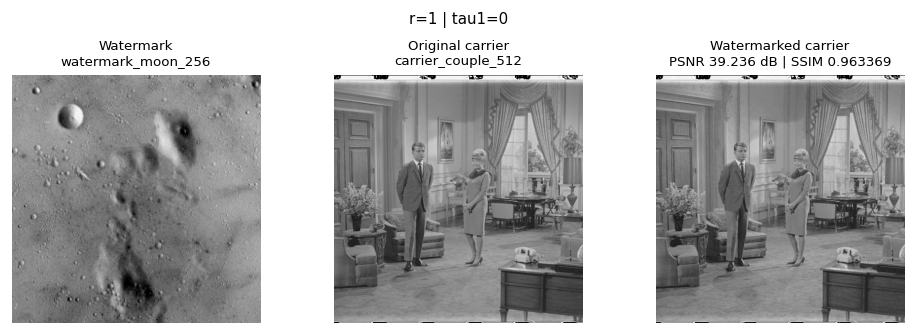

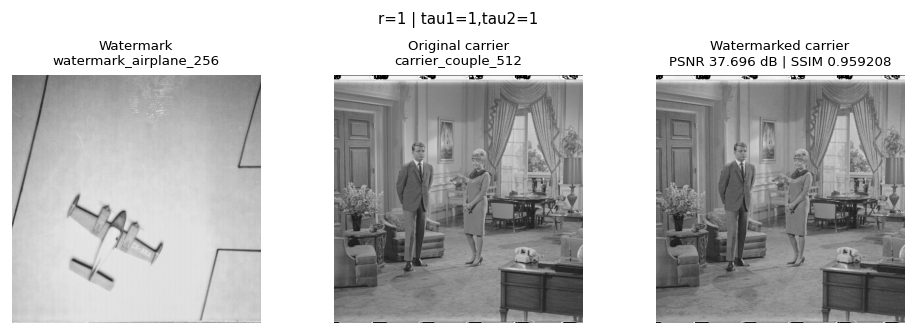

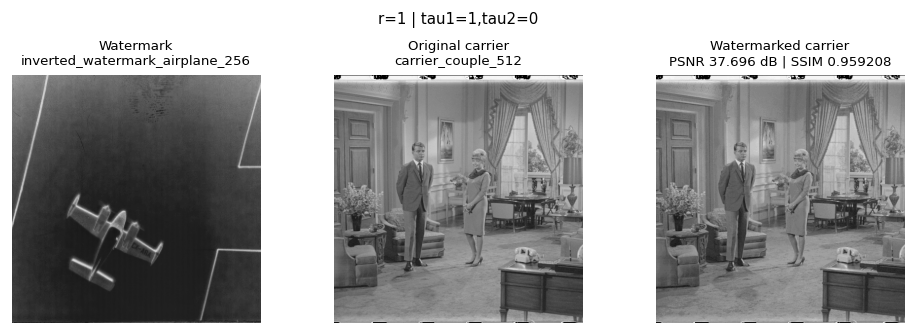

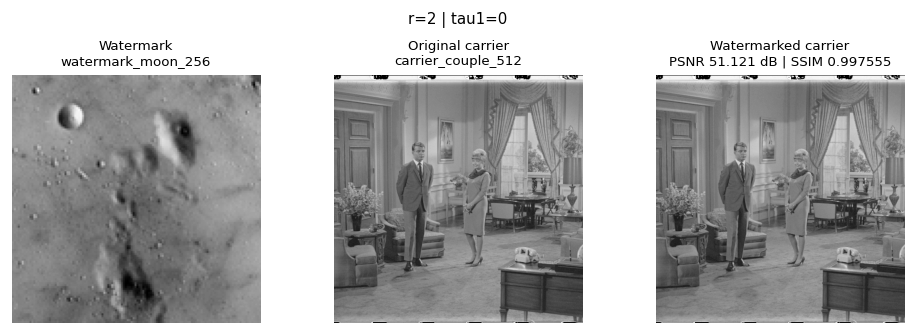

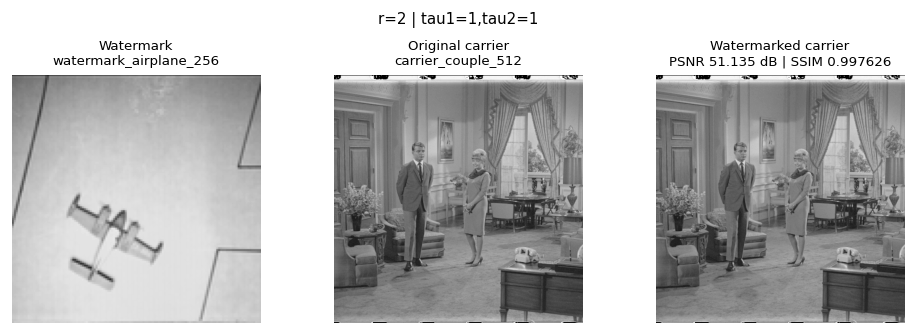

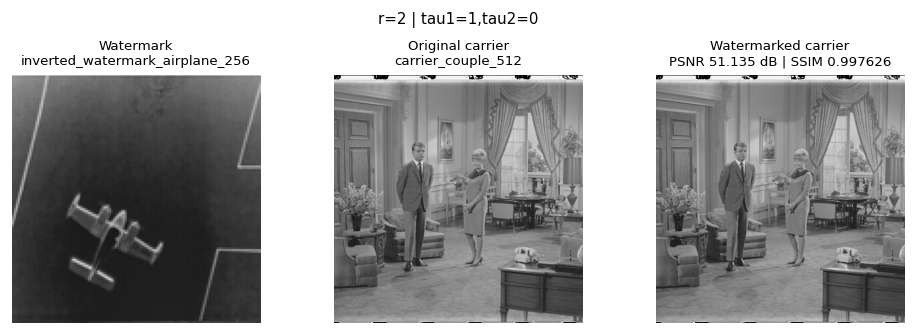

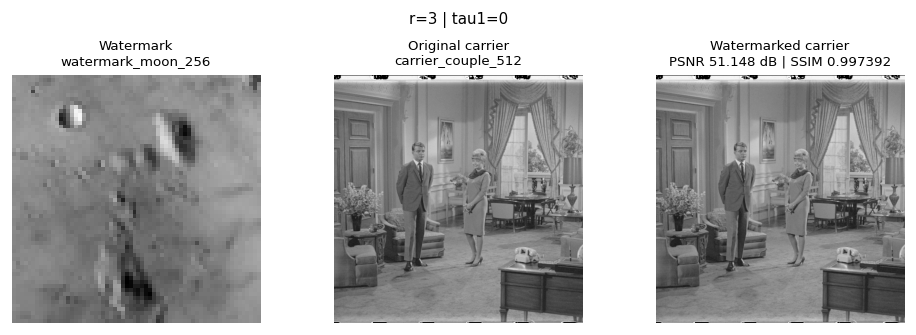

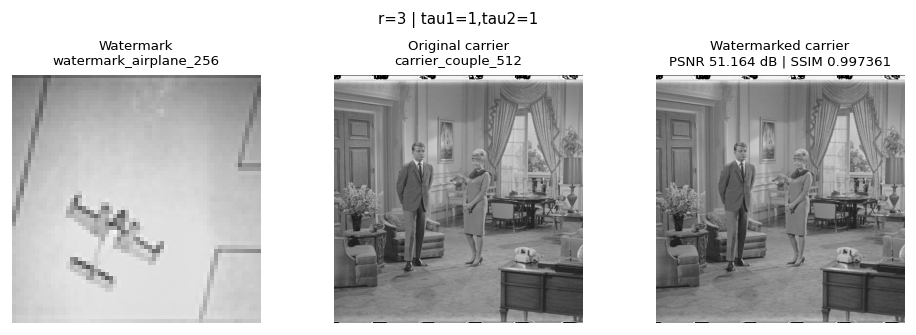

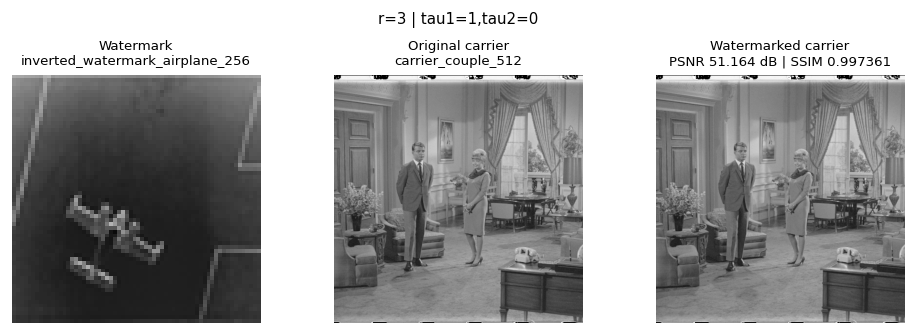

In [8]:
for r in R_VALUES:
    for branch in BRANCH_ORDER:
        subset = [record for record in records if record["r"] == r and record["branch"] == branch]
        if not subset:
            continue
        show_carrier_result(subset[0])


In [9]:
print("Paper visual-quality reference means from paper_analysis/paper_analysis.md:")
print("  r=1: PSNR 36.78 dB, SSIM 0.9693")
print("  r=2: PSNR 51.25 dB, SSIM 0.9982")
print("  r=3: PSNR 51.15 dB, SSIM 0.9981")
print()
print("This notebook uses USC-SIPI watermark sources instead of the paper's unavailable Elsevier watermark image.")


Paper visual-quality reference means from paper_analysis/paper_analysis.md:
  r=1: PSNR 36.78 dB, SSIM 0.9693
  r=2: PSNR 51.25 dB, SSIM 0.9982
  r=3: PSNR 51.15 dB, SSIM 0.9981

This notebook uses USC-SIPI watermark sources instead of the paper's unavailable Elsevier watermark image.
